In [ ]:
!git clone https://github.com/d4-5/NLP4.git
%cd NLP4

In [ ]:
!pip install -r requirements.txt

In [ ]:
%cd NLP4

In [2]:
from pathlib import Path
import pandas as pd
import sys

root = Path('..').resolve()
DATA_DIR = root / 'data'
sys.path.append(str(root))
PROCESSED_PATH = DATA_DIR / 'processed_v2.csv'
LABELS_PATH = DATA_DIR / 'labels.csv'
SPLIT_DIR = DATA_DIR / 'sample'

In [3]:
from src.classification_baseline import (
    load_processed, load_labels, attach_labels, load_split_ids, filter_by_ids
)

processed = load_processed(PROCESSED_PATH)
labels = load_labels(LABELS_PATH)
data = attach_labels(processed, labels)

splits = load_split_ids(SPLIT_DIR)
train_df = filter_by_ids(data, splits['train'])
val_df = filter_by_ids(data, splits['val'])
test_df = filter_by_ids(data, splits['test'])

print('sizes:', {
    'train': len(train_df),
    'val': len(val_df),
    'test': len(test_df),
})

label_dist = (train_df['dominant_label']
    .value_counts(dropna=False)
    .rename_axis('label')
    .reset_index(name='count'))
label_dist


sizes: {'train': 8929, 'val': 1116, 'test': 1116}


,label,count
0,NO_ENTITY,4657
1,PERS,1348
2,ORG,804
3,LOC,684
4,DATE,406
5,JOB,338
6,ART,188
7,MISC,151
8,MON,144
9,PERIOD,88


In [4]:
X_train = train_df['text_clean'].fillna('')
y_train = train_df['dominant_label']
X_val = val_df['text_clean'].fillna('')
y_val = val_df['dominant_label']
X_test = test_df['text_clean'].fillna('')
y_test = test_df['dominant_label']


In [5]:
from src.classification_baseline import (
    BaselineConfig, build_pipeline, evaluate_split, full_report
)

baseline1_cfg = BaselineConfig(ngram_range=(1, 1), max_iter=400)
baseline1 = build_pipeline(baseline1_cfg)
baseline1.fit(X_train, y_train)

b1_train = evaluate_split(baseline1, X_train, y_train)
b1_val = evaluate_split(baseline1, X_val, y_val)
b1_test = evaluate_split(baseline1, X_test, y_test)
b1_train, b1_val, b1_test


({'accuracy': 0.7341247620114234, 'macro_f1': np.float64(0.35558469276265664)},
 {'accuracy': 0.6353046594982079, 'macro_f1': np.float64(0.24946718297035544)},
 {'accuracy': 0.6164874551971327, 'macro_f1': np.float64(0.21999254732034673)})

In [6]:
baseline2_cfg = BaselineConfig(ngram_range=(1, 2), max_iter=400)
baseline2 = build_pipeline(baseline2_cfg)
baseline2.fit(X_train, y_train)

b2_train = evaluate_split(baseline2, X_train, y_train)
b2_val = evaluate_split(baseline2, X_val, y_val)
b2_test = evaluate_split(baseline2, X_test, y_test)
b2_train, b2_val, b2_test


({'accuracy': 0.6959345951394333, 'macro_f1': np.float64(0.310652152431722)},
 {'accuracy': 0.6200716845878136, 'macro_f1': np.float64(0.2322232489619227)},
 {'accuracy': 0.6146953405017921, 'macro_f1': np.float64(0.21623833864638642)})

In [7]:
import pandas as pd

metrics_rows = [
    {'baseline': 'B1_word_1_1', 'split': 'train', **b1_train},
    {'baseline': 'B1_word_1_1', 'split': 'val', **b1_val},
    {'baseline': 'B1_word_1_1', 'split': 'test', **b1_test},
    {'baseline': 'B2_word_1_2', 'split': 'train', **b2_train},
    {'baseline': 'B2_word_1_2', 'split': 'val', **b2_val},
    {'baseline': 'B2_word_1_2', 'split': 'test', **b2_test},
]
metrics_df = pd.DataFrame(metrics_rows)
metrics_df


,baseline,split,accuracy,macro_f1
0,B1_word_1_1,train,0.734125,0.355585
1,B1_word_1_1,val,0.635305,0.249467
2,B1_word_1_1,test,0.616487,0.219993
3,B2_word_1_2,train,0.695935,0.310652
4,B2_word_1_2,val,0.620072,0.232223
5,B2_word_1_2,test,0.614695,0.216238


In [8]:
best_name = 'B1_word_1_1' if b1_val['macro_f1'] >= b2_val['macro_f1'] else 'B2_word_1_2'
best_model = baseline1 if best_name == 'B1_word_1_1' else baseline2
best_name


'B1_word_1_1'

In [9]:
print(full_report(best_model, X_test, y_test))

              precision    recall  f1-score   support

         ART       1.00      0.13      0.23        23
        DATE       0.59      0.39      0.47        51
         DOC       0.00      0.00      0.00         5
         JOB       0.00      0.00      0.00        42
         LOC       0.52      0.14      0.22        86
        MISC       0.00      0.00      0.00        19
         MON       0.73      0.61      0.67        18
   NO_ENTITY       0.62      0.98      0.76       582
         ORG       0.55      0.48      0.51       100
         PCT       0.00      0.00      0.00         4
      PERIOD       0.00      0.00      0.00        11
        PERS       0.59      0.13      0.21       168
       QUANT       0.00      0.00      0.00         6
        TIME       0.00      0.00      0.00         1

    accuracy                           0.62      1116
   macro avg       0.33      0.20      0.22      1116
weighted avg       0.56      0.62      0.53      1116



/home/user/lababd6/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/user/lababd6/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/user/lababd6/venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


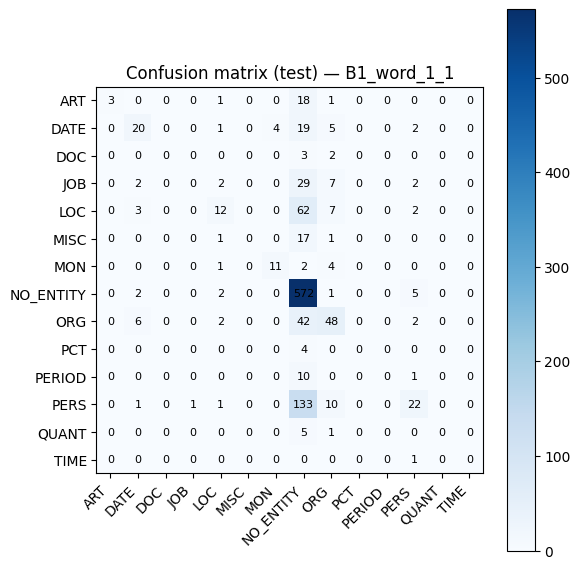

In [10]:
import matplotlib.pyplot as plt
from src.classification_baseline import get_confusion

cm_df, labels_order = get_confusion(best_model, X_test, y_test)

plt.figure(figsize=(6, 6))
plt.imshow(cm_df.values, cmap='Blues')
plt.xticks(range(len(labels_order)), labels_order, rotation=45, ha='right')
plt.yticks(range(len(labels_order)), labels_order)
plt.title(f'Confusion matrix (test) — {best_name}')
plt.colorbar()

for i in range(len(labels_order)):
    for j in range(len(labels_order)):
        val = cm_df.values[i, j]
        plt.text(j, i, str(val), ha='center', va='center', fontsize=8)

plt.tight_layout()
plt.show()


In [11]:
from src.classification_baseline import top_features

top_pos = top_features(best_model, top_k=10, negative=False)
top_pos


{'ART': [('це', 2.758800780462146),
  ('про', 2.517547301115866),
  ('віснику', 2.20915680830395),
  ('пише', 2.094940272368351),
  ('закупівель', 1.9030724855567152),
  ('державних', 1.8953302268248824),
  ('повідомляється', 1.834214682554396),
  ('sofia', 1.8152121480025951),
  ('наші', 1.6731856333145059),
  ('наших', 1.5239369818582316)],
 'DATE': [('року', 8.037334197692005),
  ('році', 6.317728904962063),
  ('2015', 2.472643971295057),
  ('свідчить', 2.2239277067827037),
  ('2011', 2.03793315612571),
  ('суду', 1.8483366773204741),
  ('2013', 1.6434902631548982),
  ('го', 1.513251536575761),
  ('липня', 1.5028280688333295),
  ('березні', 1.4881707472891204)],
 'DOC': [('про', 2.0002192715225733),
  ('від', 1.7448431573237506),
  ('свідчить', 1.6394469668419205),
  ('суду', 1.304727672545833),
  ('ухвала', 1.3027001973604115),
  ('постанова', 0.8365405035573017),
  ('україни', 0.8033724389321885),
  ('відповідно', 0.7731592657125917),
  ('це', 0.7527420853370425),
  ('лютого', 0.7

In [12]:
test_preds = best_model.predict(X_test)
errors = test_df.copy()
errors['pred_label'] = test_preds
errors = errors[errors['pred_label'] != errors['dominant_label']]

error_samples = errors[['text_id', 'text_clean', 'dominant_label', 'pred_label']].copy()
error_samples = error_samples.rename(columns={
    'text_clean': 'text',
    'dominant_label': 'gold_label',
    'pred_label': 'pred_label',
})

error_samples = error_samples.sample(n=min(10, len(error_samples)), random_state=42)
error_samples['comment'] = ''
error_samples


,text_id,text,gold_label,pred_label,comment
10996,text_10996,"Досудовим розслідуванням встановлено, що посад...",MISC,ORG,
2419,text_2419,"Про проблему заговорили й в Україні, спершу пе...",LOC,NO_ENTITY,
5485,text_5485,"Утім, одночасно з вироком було видано монаршу ...",PERS,NO_ENTITY,
858,text_858,"Дуже шкодувала, що вас із Богданчиком не було ...",PERS,NO_ENTITY,
9865,text_9865,"Відомо, що вартість робіт до закінчення цього ...",DATE,MON,
7824,text_7824,"А завтра зранку, прошу тебе дуже, погуляй зі м...",DATE,NO_ENTITY,
5113,text_5113,Бойовики на місці розстрілу показували на каме...,PERS,NO_ENTITY,
5085,text_5085,"Коли Олексій уперше став ногами на цю землю, т...",PERS,NO_ENTITY,
5155,text_5155,"Хоч вона ще не дійшла до кінця, по настилу вже...",PERS,NO_ENTITY,
5444,text_5444,"Він пройшов увесь цей шлях, бо сподівався, що ...",MISC,NO_ENTITY,


In [13]:
comments = {
    'text_10996': 'Юридичний контекст з організаційною лексикою → модель тягнеться до ORG, хоча у gold це MISC.',
    'text_2419': 'Локація згадана непрямо/без чітких топонімів, тому модель віднесла до NO_ENTITY.',
    'text_5485': 'Персона позначена титулом/контекстом без імені — слабкий сигнал для PERS.',
    'text_858': 'Ім’я у зменшувальній формі або рідковживане, модель не впізнала PERS.',
    'text_9865': 'Грошовий контекст домінує, тому DATE сплуталась з MON.',
    'text_7824': 'Темпоральний маркер типу “завтра/зранку” слабкий → NO_ENTITY.',
    'text_5113': 'Є згадка людей без власних імен (роль/група) — модель не віднесла до PERS.',
    'text_5085': 'Власне ім’я є, але контекст короткий/зашумлений — PERS пропущено.',
    'text_5155': 'Персона реферується займенником, відсутні явні іменні сигнали.',
    'text_5444': 'Абстрактна/подієва згадка, слабкі ключові слова для MISC.',
}
error_samples['comment'] = error_samples['text_id'].map(comments).fillna(error_samples['comment'])
error_samples


,text_id,text,gold_label,pred_label,comment
10996,text_10996,"Досудовим розслідуванням встановлено, що посад...",MISC,ORG,Юридичний контекст з організаційною лексикою →...
2419,text_2419,"Про проблему заговорили й в Україні, спершу пе...",LOC,NO_ENTITY,"Локація згадана непрямо/без чітких топонімів, ..."
5485,text_5485,"Утім, одночасно з вироком було видано монаршу ...",PERS,NO_ENTITY,Персона позначена титулом/контекстом без імені...
858,text_858,"Дуже шкодувала, що вас із Богданчиком не було ...",PERS,NO_ENTITY,"Ім’я у зменшувальній формі або рідковживане, м..."
9865,text_9865,"Відомо, що вартість робіт до закінчення цього ...",DATE,MON,"Грошовий контекст домінує, тому DATE сплуталас..."
7824,text_7824,"А завтра зранку, прошу тебе дуже, погуляй зі м...",DATE,NO_ENTITY,Темпоральний маркер типу “завтра/зранку” слабк...
5113,text_5113,Бойовики на місці розстрілу показували на каме...,PERS,NO_ENTITY,Є згадка людей без власних імен (роль/група) —...
5085,text_5085,"Коли Олексій уперше став ногами на цю землю, т...",PERS,NO_ENTITY,"Власне ім’я є, але контекст короткий/зашумлени..."
5155,text_5155,"Хоч вона ще не дійшла до кінця, по настилу вже...",PERS,NO_ENTITY,"Персона реферується займенником, відсутні явні..."
5444,text_5444,"Він пройшов увесь цей шлях, бо сподівався, що ...",MISC,NO_ENTITY,"Абстрактна/подієва згадка, слабкі ключові слов..."


In [14]:
from pathlib import Path

out_path = Path('tests') / 'error_cases_lab6.jsonl'
out_path.parent.mkdir(parents=True, exist_ok=True)
error_samples.to_json(out_path, orient='records', lines=True, force_ascii=False)
out_path


PosixPath('tests/error_cases_lab6.jsonl')

### Висновок з error analysis
Найчастіші помилки — коли модель обирає `NO_ENTITY` замість сутності, особливо для `PERS` та `LOC`.
Другий тип — перекриття типів: `DATE` плутається з `MON` або `PERIOD`, а `ORG` з `MISC`.
Третій тип — короткі та контекстно слабкі фрагменти, де модель не бачить достатньо сигналів у n-граммах.
Першим кроком варто спробувати `class_weight="balanced"` і/або лематизацію, щоб зменшити домінування `NO_ENTITY`.
Також допоможе додати прості регулярні ознаки для дат і сум, щоб відрізняти `DATE` vs `MON`/`PERIOD`.
Найбільший приріст очікую від балансування класів і чищення/уточнення розмітки у спірних прикладах.
